# Exploratory Data Analysis (EDA)

## Intelligent Customer Analytics Platform

### Objective

The purpose of this notebook is to explore the cleaned Online Retail dataset, understand customer purchasing behavior, identify business patterns, detect anomalies, and generate insights that will guide feature engineering and machine learning.

---

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Figure Size
plt.rcParams["figure.figsize"] = (12,6)

# Theme
sns.set_style("whitegrid")

# Font Size
plt.rcParams["font.size"] = 12

In [3]:
# Load the canonical dataset produced by src/data/cleaner.py
# (already has the canonical column names and time-based features)
df = pd.read_csv("../data/processed/final_cleaned_dataset.csv")


In [4]:
# NOTE: Renaming (Invoice -> InvoiceNo, Price -> UnitPrice,
# "Customer ID" -> CustomerID, TotalAmount -> Revenue) now happens
# inside src/data/cleaner.py, so the dataset loaded above already
# uses the canonical column names. No renaming needed here.


In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue,...,Month,MonthName,Day,DayName,Hour,Quarter,DayOfWeek,Week,IsWeekend,TimeOfDay
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,...,12,December,1,Tuesday,7,4,1,49,False,Morning
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,...,12,December,1,Tuesday,7,4,1,49,False,Morning
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,...,12,December,1,Tuesday,7,4,1,49,False,Morning
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,...,12,December,1,Tuesday,7,4,1,49,False,Morning
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,...,12,December,1,Tuesday,7,4,1,49,False,Morning


In [6]:
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 797815
Columns : 21


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797815 entries, 0 to 797814
Data columns (total 21 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    797815 non-null  object 
 1   StockCode    797815 non-null  object 
 2   Description  797815 non-null  object 
 3   Quantity     797815 non-null  int64  
 4   InvoiceDate  797815 non-null  object 
 5   UnitPrice    797815 non-null  float64
 6   CustomerID   797815 non-null  float64
 7   Country      797815 non-null  object 
 8   IsCancelled  797815 non-null  bool   
 9   Revenue      797815 non-null  float64
 10  Year         797815 non-null  int64  
 11  Month        797815 non-null  int64  
 12  MonthName    797815 non-null  object 
 13  Day          797815 non-null  int64  
 14  DayName      797815 non-null  object 
 15  Hour         797815 non-null  int64  
 16  Quarter      797815 non-null  int64  
 17  DayOfWeek    797815 non-null  int64  
 18  Week         797815 non-

In [8]:
list(df.columns)

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country',
 'IsCancelled',
 'Revenue',
 'Year',
 'Month',
 'MonthName',
 'Day',
 'DayName',
 'Hour',
 'Quarter',
 'DayOfWeek',
 'Week',
 'IsWeekend',
 'TimeOfDay']

In [9]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
IsCancelled       bool
Revenue        float64
Year             int64
Month            int64
MonthName       object
Day              int64
DayName         object
Hour             int64
Quarter          int64
DayOfWeek        int64
Week             int64
IsWeekend         bool
TimeOfDay       object
dtype: object

In [10]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [11]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
IsCancelled              bool
Revenue               float64
Year                    int64
Month                   int64
MonthName              object
Day                     int64
DayName                object
Hour                    int64
Quarter                 int64
DayOfWeek               int64
Week                    int64
IsWeekend                bool
TimeOfDay              object
dtype: object

In [12]:
missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().mean() * 100).round(2)
})

missing_df

,Missing Values,Percentage
InvoiceNo,0,0.0
StockCode,0,0.0
Description,0,0.0
Quantity,0,0.0
InvoiceDate,0,0.0
UnitPrice,0,0.0
CustomerID,0,0.0
Country,0,0.0
IsCancelled,0,0.0
Revenue,0,0.0


In [13]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [14]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,Year,Month,Day,Hour,Quarter,DayOfWeek,Week
count,797815.000000,797815,797815.000000,797815.000000,797815.000000,797815.000000,797815.000000,797815.000000,797815.000000,797815.000000,797815.000000,797815.000000
mean,12.585594,2011-01-02 13:15:39.345813504,3.703057,15313.157440,20.418256,2010.431109,7.411384,15.387526,12.800976,2.795003,2.632767,30.102329
min,-80995.000000,2009-12-01 07:45:00,0.001000,12346.000000,-168469.600000,2009.000000,1.000000,1.000000,6.000000,1.000000,0.000000,1.000000
25%,2.000000,2010-07-02 09:47:00,1.250000,13964.000000,4.350000,2010.000000,5.000000,8.000000,11.000000,2.000000,1.000000,18.000000
50%,5.000000,2010-12-02 12:33:00,1.950000,15228.000000,11.700000,2010.000000,8.000000,15.000000,13.000000,3.000000,2.000000,33.000000
75%,12.000000,2011-07-31 15:50:00,3.750000,16789.000000,19.500000,2011.000000,10.000000,23.000000,14.000000,4.000000,4.000000,44.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,21.000000,4.000000,6.000000,52.000000
std,191.163061,NaN,71.395672,1696.437628,313.532519,0.568895,3.424469,8.658267,2.306712,1.132428,1.944577,14.848352


## Initial Observations

- The dataset contains **797,815 cleaned transactions** and **10 columns**.
- Revenue has been successfully calculated.
- Missing values have been removed.
- Duplicate records have been handled.
- Data types are appropriate for analysis.
- The dataset is ready for exploratory data analysis.

# 2. Univariate Analysis

In this section, we analyze each variable individually to understand its distribution, identify outliers, and derive business insights.

For every variable, we will examine:

- Statistical summary
- Distribution
- Outliers
- Business interpretation

### Variable 1 — Quantity

## 2.1 Quantity Analysis

Quantity represents the number of units purchased in each transaction.

Objectives:

- Understand purchase quantities.
- Identify unusually large orders.
- Detect potential outliers.

In [15]:
df["Quantity"].describe()

count    797815.000000
mean         12.585594
std         191.163061
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [16]:
print("Skewness :", df["Quantity"].skew())

Skewness : 4.8566157191868795


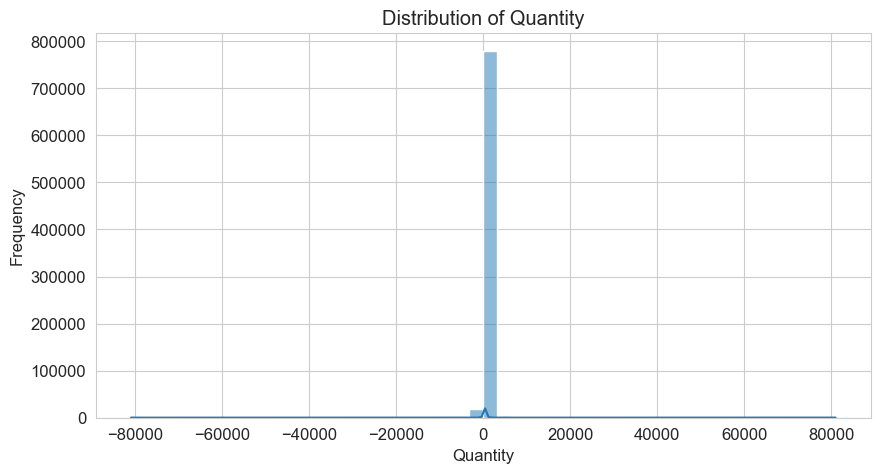

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Quantity",
    bins=50,
    kde=True
)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

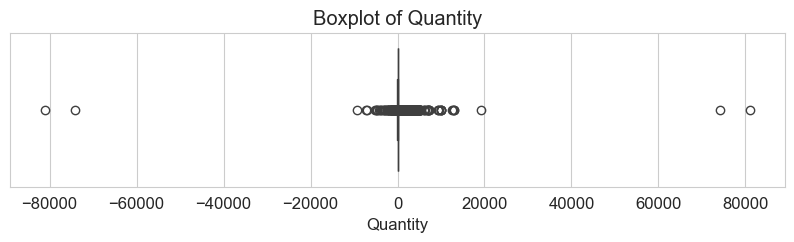

In [18]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["Quantity"]
)

plt.title("Boxplot of Quantity")

plt.show()

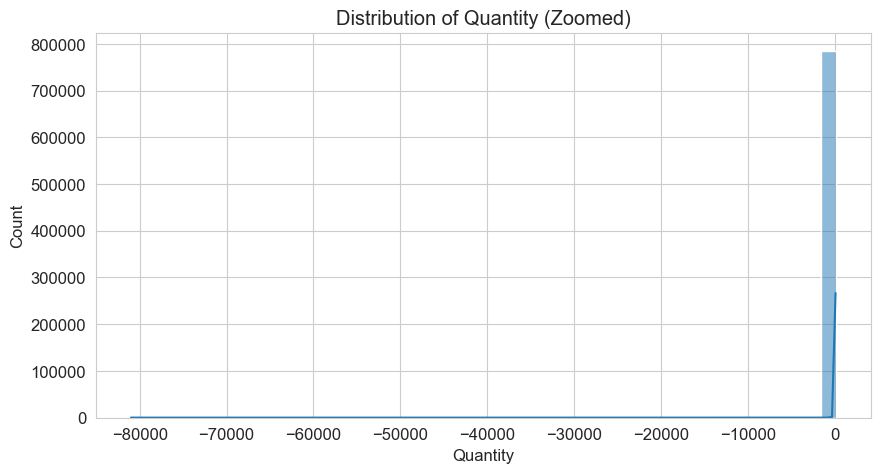

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(
    df[df["Quantity"] < 100]["Quantity"],
    bins=50,
    kde=True
)

plt.title("Distribution of Quantity (Zoomed)")
plt.show()

### Interpretation

- Most transactions involve relatively small purchase quantities.
- The distribution is positively skewed.
- Several extreme outliers are visible.
- A small number of transactions contain unusually large quantities.

### Business Insight

Most customers purchase only a few items per transaction, while a limited number of wholesale or bulk purchases contribute to the extreme values. These observations should be considered carefully before feature engineering and modeling.

### Variable 2 — UnitPrice

## 2.2 Unit Price Analysis

UnitPrice represents the selling price of one unit of a product.

Objectives:

- Understand pricing distribution.
- Detect unusually expensive products.
- Identify potential pricing errors.

In [20]:
df["UnitPrice"].describe()

count    797815.000000
mean          3.703057
std          71.395672
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max       38970.000000
Name: UnitPrice, dtype: float64

In [21]:
print(df["UnitPrice"].skew())

306.22985040541147


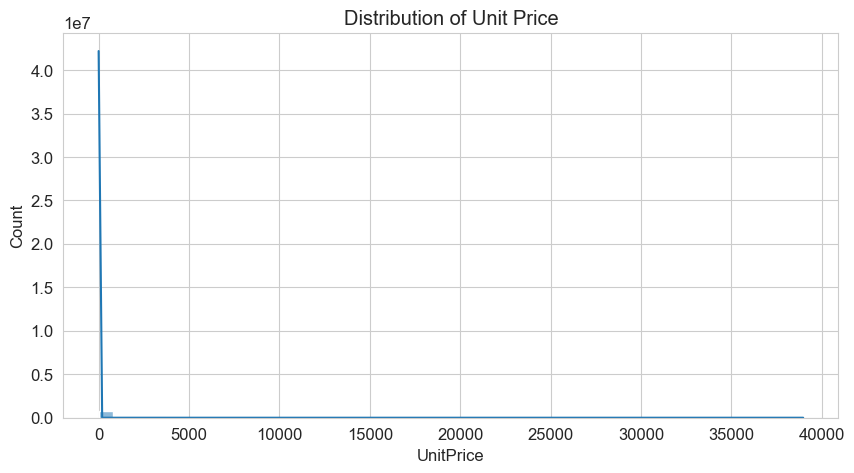

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="UnitPrice",
    bins=50,
    kde=True
)

plt.title("Distribution of Unit Price")

plt.show()

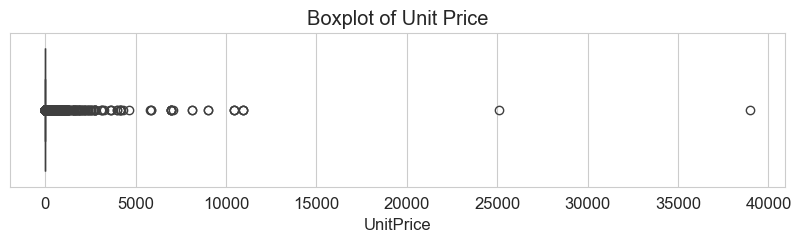

In [23]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["UnitPrice"]
)

plt.title("Boxplot of Unit Price")

plt.show()

### Interpretation

- The majority of products are priced at the lower end of the pricing spectrum.
- The distribution is strongly right-skewed.
- A small number of products have exceptionally high prices.

### Business Insight

The product catalog contains many low-cost items and relatively few premium-priced products. These high-value products should be investigated further because they can significantly influence revenue and customer value analyses.

### Variable 3 — Revenue

In [24]:
df["Revenue"].describe()

count    797815.000000
mean         20.418256
std         313.532519
min     -168469.600000
25%           4.350000
50%          11.700000
75%          19.500000
max      168469.600000
Name: Revenue, dtype: float64

In [25]:
print("Skewness :", df["Revenue"].skew())

Skewness : -0.6094196009019449


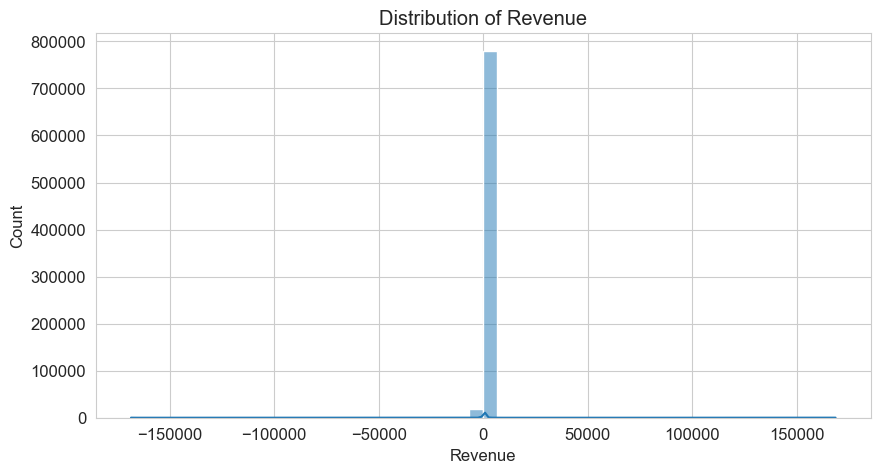

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Revenue",
    bins=50,
    kde=True
)

plt.title("Distribution of Revenue")

plt.show()

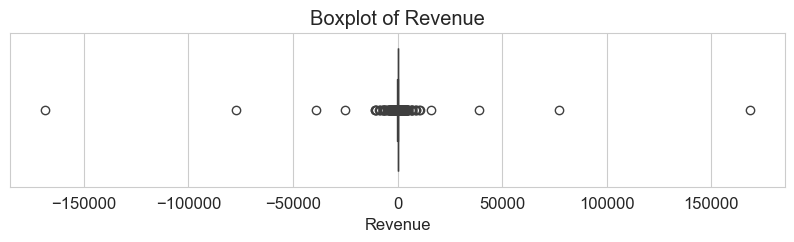

In [27]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["Revenue"]
)

plt.title("Boxplot of Revenue")

plt.show()

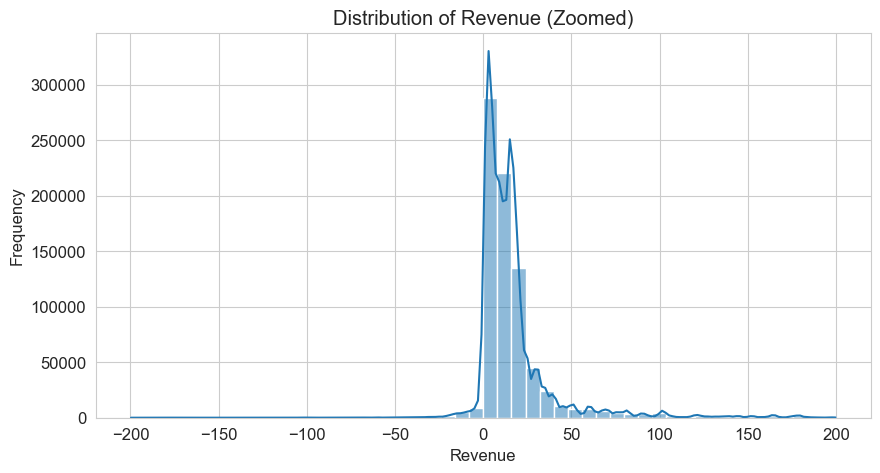

In [28]:
plt.figure(figsize=(10,5))

sns.histplot(
    df[(df["Revenue"] > -200) & (df["Revenue"] < 200)]["Revenue"],
    bins=50,
    kde=True
)

plt.title("Distribution of Revenue (Zoomed)")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

### Interpretation

- Most transactions generate relatively low revenue, indicating that customers typically make small-value purchases.
- The average transaction revenue ($20.42) is higher than the median ($11.70), suggesting that a small number of high-value transactions increase the overall average.
- Revenue contains both large positive and large negative values. The negative revenue values correspond to cancelled orders or product returns, while the positive extremes represent bulk or high-value purchases.
- The distribution contains several extreme outliers, which compress the histogram and indicate substantial variability in transaction values.
- Although the calculated skewness is slightly negative (-0.61), this is influenced by the presence of large negative revenue values from returns. Therefore, the histogram and boxplot should be interpreted together with the summary statistics rather than relying solely on the skewness value.

### Business Insight

The business generates revenue primarily through a large volume of low-value transactions, while a relatively small number of high-value purchases contribute disproportionately to total revenue. Additionally, product returns and cancelled orders create significant negative revenue values, emphasizing the need to monitor return behavior and its financial impact. Understanding these high-value and negative transactions can help improve revenue forecasting, inventory management, and customer retention strategies.

### Variable 4 — Country

In [29]:
df["Country"].value_counts()

Country
United Kingdom          716069
Germany                  17331
EIRE                     16012
France                   13896
Netherlands               5132
Spain                     3753
Belgium                   3109
Switzerland               3057
Portugal                  2414
Australia                 1887
Channel Islands           1646
Italy                     1507
Sweden                    1343
Norway                    1307
Cyprus                    1157
Finland                   1049
Austria                    938
Denmark                    797
Greece                     663
Japan                      565
USA                        535
Poland                     527
Unspecified                521
United Arab Emirates       386
Singapore                  346
Israel                     321
Malta                      299
Canada                     228
Iceland                    222
Lithuania                  154
RSA                        122
Brazil                      94


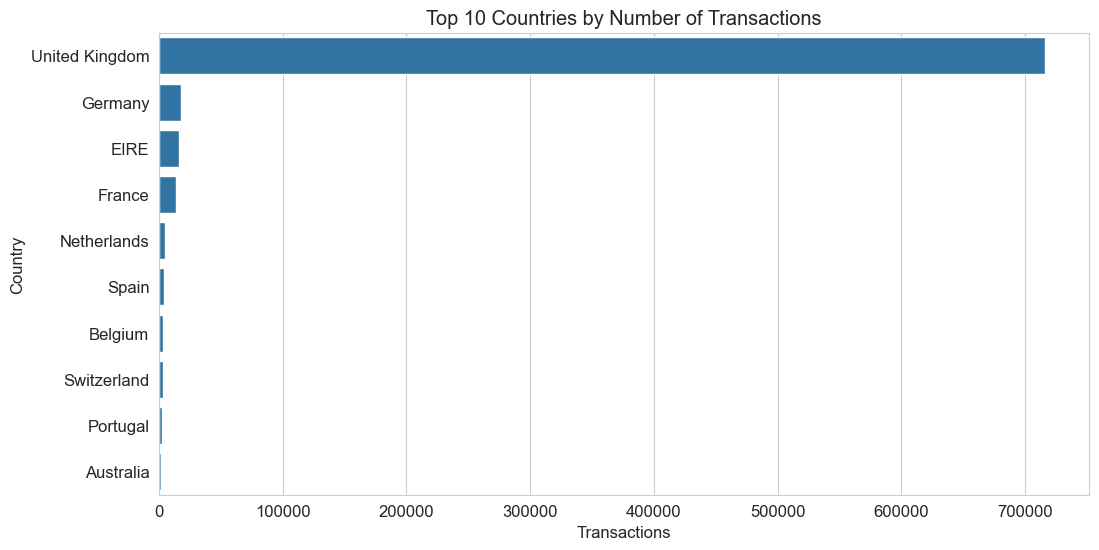

In [30]:
top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Number of Transactions")

plt.xlabel("Transactions")

plt.ylabel("Country")

plt.show()

### Variable 5 — IsCancelled

In [31]:
df["IsCancelled"].value_counts()

IsCancelled
False    779425
True      18390
Name: count, dtype: int64

In [32]:
cancel_rate = (
    df["IsCancelled"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(cancel_rate)

IsCancelled
False    97.69
True      2.31
Name: proportion, dtype: float64


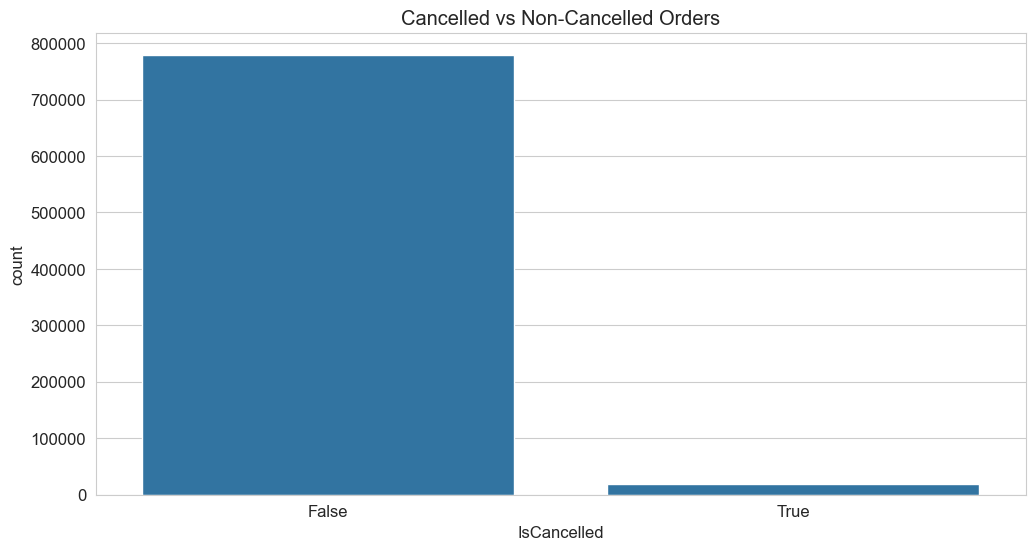

In [33]:
sns.countplot(
    data=df,
    x="IsCancelled"
)

plt.title("Cancelled vs Non-Cancelled Orders")

plt.show()

# 3. Numerical Features Summary

The following table summarizes the statistical characteristics of the numerical variables analyzed during Exploratory Data Analysis.

This summary provides a quick overview of:

- Central tendency
- Variability
- Distribution shape
- Presence of outliers
- Business observations

In [34]:
numerical_summary = pd.DataFrame({
    "Feature": ["Quantity", "UnitPrice", "Revenue"],

    "Mean": [
        round(df["Quantity"].mean(),2),
        round(df["UnitPrice"].mean(),2),
        round(df["Revenue"].mean(),2)
    ],

    "Median": [
        round(df["Quantity"].median(),2),
        round(df["UnitPrice"].median(),2),
        round(df["Revenue"].median(),2)
    ],

    "Std Dev": [
        round(df["Quantity"].std(),2),
        round(df["UnitPrice"].std(),2),
        round(df["Revenue"].std(),2)
    ],

    "Skewness": [
        round(df["Quantity"].skew(),2),
        round(df["UnitPrice"].skew(),2),
        round(df["Revenue"].skew(),2)
    ],

    "Minimum": [
        df["Quantity"].min(),
        df["UnitPrice"].min(),
        df["Revenue"].min()
    ],

    "Maximum": [
        df["Quantity"].max(),
        df["UnitPrice"].max(),
        df["Revenue"].max()
    ]
})

numerical_summary

,Feature,Mean,Median,Std Dev,Skewness,Minimum,Maximum
0,Quantity,12.59,5.00,191.16,4.86,-80995.000,80995.0
1,UnitPrice,3.70,1.95,71.40,306.23,0.001,38970.0
2,Revenue,20.42,11.70,313.53,-0.61,-168469.600,168469.6


### Observations

- Quantity and UnitPrice exhibit strong positive skewness, indicating that most transactions involve small purchase quantities and low-priced products.
- Revenue displays substantial variability due to both high-value purchases and negative revenue generated by returns or cancelled transactions.
- Large differences between the mean and median values indicate the presence of extreme outliers.
- All numerical features contain significant outliers that should be considered carefully during feature engineering and predictive modeling.

# 4. Categorical Features Summary

The following section summarizes the important categorical variables and highlights the major patterns identified during Exploratory Data Analysis.

In [35]:
categorical_summary = pd.DataFrame({

    "Feature":[
        "Country",
        "IsCancelled"
    ],

    "Unique Values":[
        df["Country"].nunique(),
        df["IsCancelled"].nunique()
    ],

    "Most Frequent":[
        df["Country"].mode()[0],
        df["IsCancelled"].mode()[0]
    ],

    "Frequency":[
        df["Country"].value_counts().iloc[0],
        df["IsCancelled"].value_counts().iloc[0]
    ]

})

categorical_summary

,Feature,Unique Values,Most Frequent,Frequency
0,Country,41,United Kingdom,716069
1,IsCancelled,2,False,779425


### Observations

- The dataset contains customers from multiple countries; however, the majority of transactions originate from the United Kingdom.
- Only a small percentage of transactions are cancelled, indicating that most orders are successfully completed.
- The dataset is geographically imbalanced, which should be considered while building predictive models.

# 5. Key Exploratory Data Analysis Findings

## Key Findings

1. The dataset contains approximately **797,815** cleaned retail transactions across multiple countries.

2. The majority of customer purchases involve relatively small quantities, while only a few transactions represent bulk orders.

3. Product prices are concentrated at the lower end of the pricing spectrum, with a limited number of premium-priced products.

4. Revenue is primarily generated through a large volume of low-value transactions, supplemented by a small number of exceptionally high-value purchases.

5. Negative revenue values indicate returned or cancelled orders and represent an important aspect of customer purchasing behavior.

6. Quantity, UnitPrice, and Revenue all contain significant outliers that may influence statistical analyses and machine learning models.

7. Nearly **97.69%** of transactions are successfully completed, while approximately **2.31%** are cancelled.

8. The United Kingdom accounts for the overwhelming majority of transactions, indicating a highly concentrated customer base.

9. The dataset exhibits highly skewed numerical distributions, suggesting that robust statistical techniques and appropriate feature transformations may be beneficial during model development.

10. Overall, the dataset is well-prepared for customer segmentation, sales analysis, predictive modeling, and business intelligence applications.

## Conclusion of Univariate Analysis

The univariate analysis provided valuable insights into the structure and characteristics of the dataset. Numerical variables exhibited significant skewness and outliers, while categorical variables revealed strong geographic concentration and a low cancellation rate.

These findings establish a solid foundation for exploring relationships between variables in the next stage of Exploratory Data Analysis.

# 6. Bivariate Analysis

Bivariate Analysis examines the relationship between two variables to identify trends, dependencies, and business insights.

This section focuses on understanding how numerical and categorical variables interact with each other.

## 6.1 Correlation Matrix

Correlation measures the strength and direction of the relationship between numerical variables.

The correlation coefficient ranges from:

- +1 → Perfect Positive Correlation
- 0 → No Correlation
- -1 → Perfect Negative Correlation

In [36]:
correlation = df[
    ["Quantity", "UnitPrice", "Revenue"]
].corr()

correlation

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.001919,0.856269
UnitPrice,-0.001919,1.000000,-0.150721
Revenue,0.856269,-0.150721,1.000000


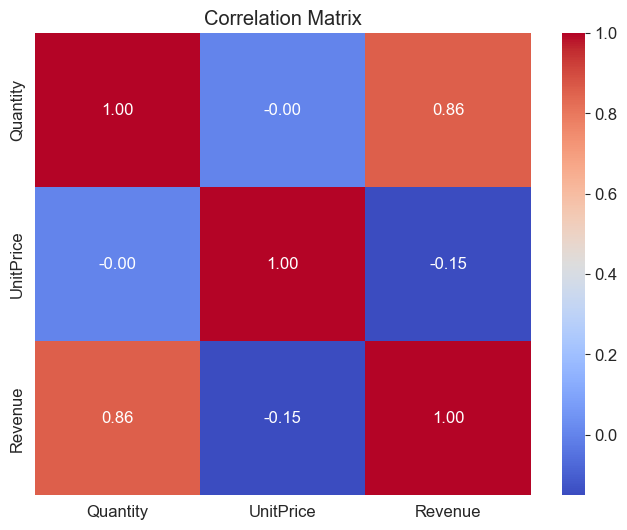

In [37]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Interpretation

- Quantity and Revenue show a strong positive correlation (0.86), indicating that larger purchase quantities generally generate higher revenue.

- Quantity and UnitPrice have almost zero correlation, suggesting that the number of items purchased is independent of the product's selling price.

- UnitPrice has a weak negative correlation with Revenue (-0.15), implying that higher-priced products do not necessarily contribute more to overall transaction revenue.

- Revenue appears to be driven primarily by purchase quantity rather than unit price.

### Business Insight

The strongest driver of transaction revenue is the quantity of products purchased rather than the selling price of individual products.

This suggests that encouraging customers to purchase larger quantities through bundle offers, discounts, or cross-selling strategies could significantly increase total revenue.

## 6.2 Pair Plot

The pair plot visualizes pairwise relationships between numerical variables and helps identify trends, clusters, and potential correlations.

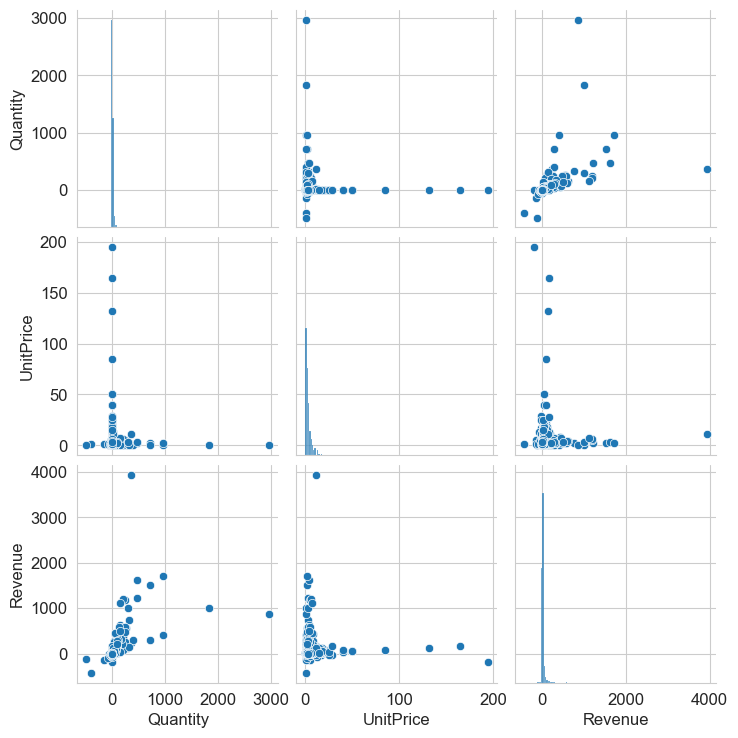

In [38]:
sample_df = df[
    ["Quantity", "UnitPrice", "Revenue"]
].sample(5000, random_state=42)

sns.pairplot(sample_df)

plt.show()

### Interpretation

- Revenue increases as purchase quantity increases, showing a strong positive relationship.

- Unit Price does not exhibit a strong linear relationship with Revenue.

- Quantity and Unit Price appear to be independent variables.

- All numerical variables contain a few extreme observations while the majority of transactions are concentrated near lower values.

### Business Insight

Customers typically purchase low-priced products in larger quantities.

The company's revenue is primarily influenced by purchase volume rather than premium pricing.

Increasing basket size through promotions, recommendations, and bundled products could have a greater impact on revenue than increasing product prices.

## 6.3 Quantity vs Revenue

This analysis examines how the number of purchased items influences transaction revenue.

Understanding this relationship helps determine whether increasing purchase quantity can significantly improve sales revenue.

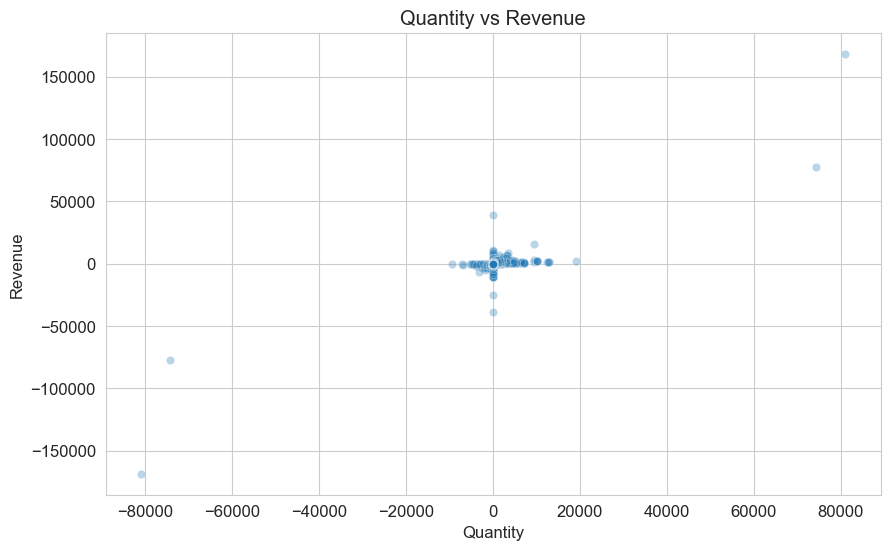

In [39]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Revenue",
    alpha=0.3
)

plt.title("Quantity vs Revenue")

plt.xlabel("Quantity")

plt.ylabel("Revenue")

plt.show()

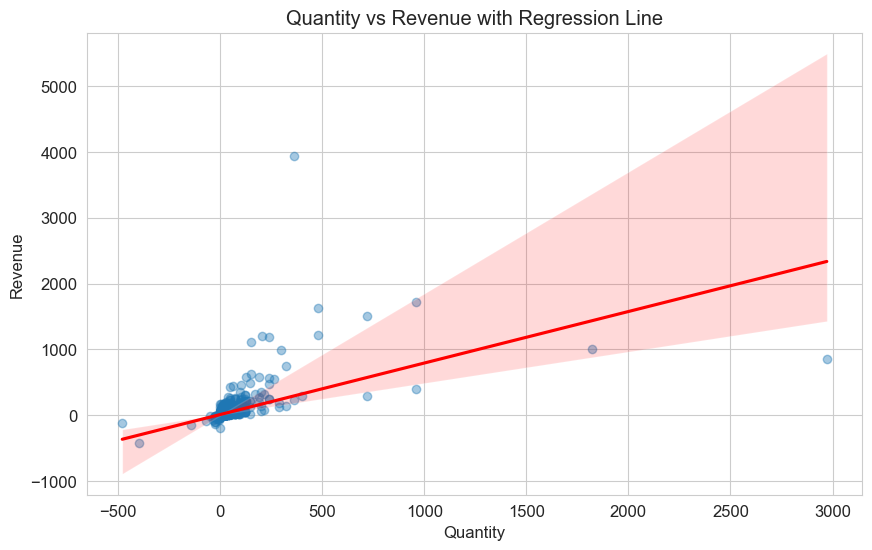

In [40]:
sample_df = df.sample(
    5000,
    random_state=42
)

plt.figure(figsize=(10,6))

sns.regplot(
    data=sample_df,
    x="Quantity",
    y="Revenue",
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"}
)

plt.title("Quantity vs Revenue with Regression Line")

plt.show()

In [41]:
corr = df["Quantity"].corr(df["Revenue"])

print(f"Correlation : {corr:.3f}")

Correlation : 0.856


In [42]:
df[
    ["Quantity", "Revenue"]
].describe()

,Quantity,Revenue
count,797815.000000,797815.000000
mean,12.585594,20.418256
std,191.163061,313.532519
min,-80995.000000,-168469.600000
25%,2.000000,4.350000
50%,5.000000,11.700000
75%,12.000000,19.500000
max,80995.000000,168469.600000


### Interpretation

- The scatter plot demonstrates a clear positive relationship between Quantity and Revenue.

- The regression line confirms that transaction revenue generally increases as customers purchase more items.

- The correlation coefficient of **0.856** indicates a strong positive association between purchase quantity and transaction revenue.

- Most transactions involve relatively small purchase quantities and generate modest revenue, while a small number of bulk purchases contribute exceptionally high revenue.

- Negative Quantity and Revenue values correspond to cancelled or returned transactions.

### Business Insight

Purchase quantity is the primary driver of transaction revenue.

Encouraging customers to purchase additional items through product bundles, cross-selling, volume discounts, and personalized recommendations can significantly increase overall sales revenue.

Bulk purchases contribute disproportionately to total revenue, making high-volume customers valuable for business growth.

## 6.4 Unit Price vs Revenue

This analysis investigates whether higher-priced products contribute to higher transaction revenue.

Understanding this relationship helps evaluate whether revenue growth is driven primarily by pricing strategy or by sales volume.

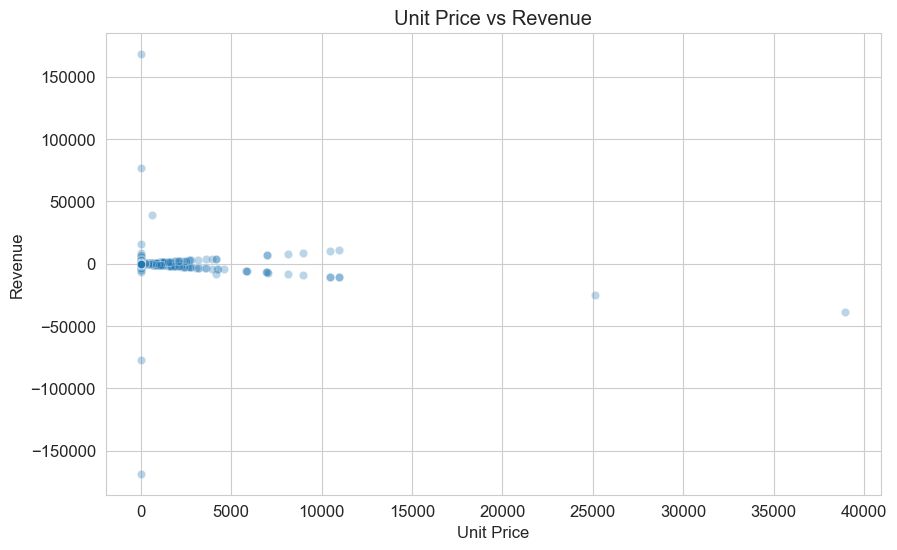

In [43]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="UnitPrice",
    y="Revenue",
    alpha=0.3
)

plt.title("Unit Price vs Revenue")

plt.xlabel("Unit Price")

plt.ylabel("Revenue")

plt.show()

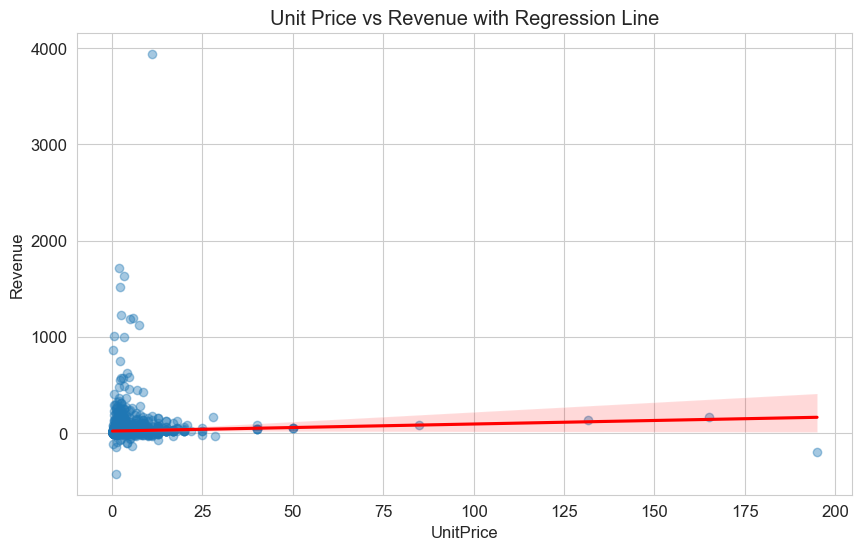

In [44]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=sample_df,
    x="UnitPrice",
    y="Revenue",
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"}
)

plt.title("Unit Price vs Revenue with Regression Line")

plt.show()

In [45]:
corr = df["UnitPrice"].corr(df["Revenue"])

print(f"Correlation : {corr:.3f}")

Correlation : -0.151


In [46]:
df[
    ["UnitPrice", "Revenue"]
].describe()

,UnitPrice,Revenue
count,797815.000000,797815.000000
mean,3.703057,20.418256
std,71.395672,313.532519
min,0.001000,-168469.600000
25%,1.250000,4.350000
50%,1.950000,11.700000
75%,3.750000,19.500000
max,38970.000000,168469.600000


### Interpretation

- The scatter plot shows no strong linear relationship between Unit Price and Revenue.

- The regression line is nearly flat, indicating that increasing product price alone does not substantially increase transaction revenue.

- The correlation coefficient (-0.151) suggests a weak negative relationship between Unit Price and Revenue.

- Most transactions involve low-priced products, while only a few products have exceptionally high prices.

- Revenue is influenced more by purchase quantity than by individual product price.

### Business Insight

Revenue is primarily generated through higher sales volume rather than premium pricing.

Customers tend to purchase lower-priced products in larger quantities, resulting in greater overall transaction revenue.

Business strategies such as bundle offers, quantity discounts, and cross-selling are likely to be more effective for revenue growth than focusing solely on increasing product prices.

# 6.5 Country vs Revenue

This section analyzes the contribution of different countries to overall revenue.

Objectives:
- Identify top revenue-generating countries.
- Compare average revenue per transaction.
- Discover geographical sales patterns.
- Generate business recommendations for market expansion.

In [47]:
country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    1.348251e+07
EIRE              5.735098e+05
Netherlands       5.483307e+05
Germany           4.119592e+05
France            3.200463e+05
Australia         1.664444e+05
Switzerland       9.877941e+04
Spain             9.101344e+04
Sweden            8.742152e+04
Denmark           6.445959e+04
Name: Revenue, dtype: float64

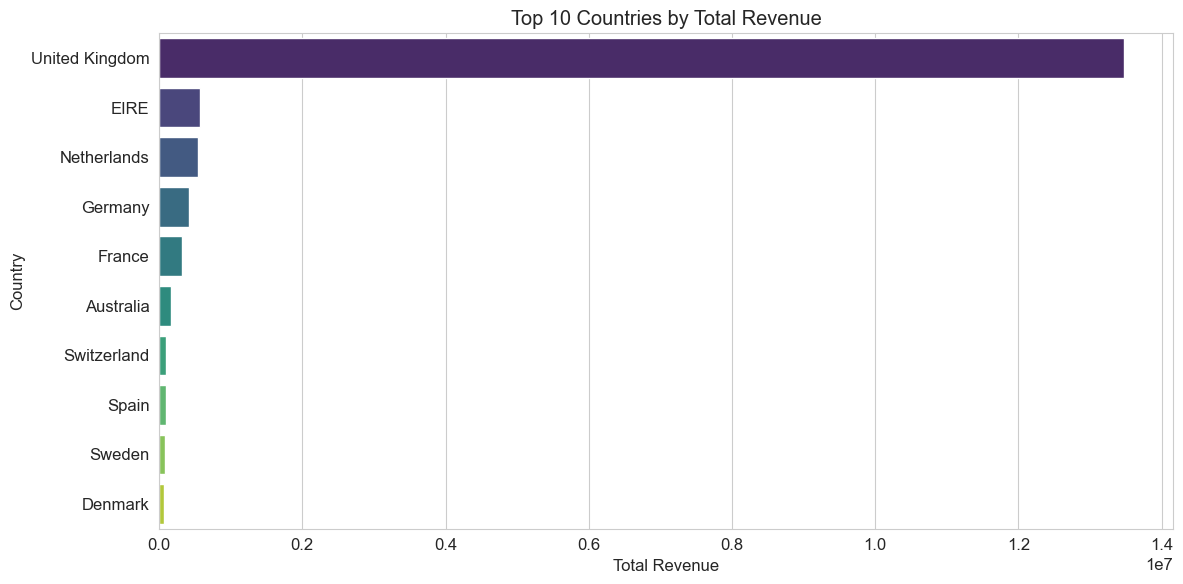

In [48]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=country_revenue.head(10).values,
    y=country_revenue.head(10).index,
    palette="viridis"
)

plt.title("Top 10 Countries by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.tight_layout()

plt.savefig(
    "../reports/figures/country_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
country_percent = (
    country_revenue /
    country_revenue.sum()
    *100
).round(2)

country_percent.head(10)

Country
United Kingdom    82.77
EIRE               3.52
Netherlands        3.37
Germany            2.53
France             1.96
Australia          1.02
Switzerland        0.61
Spain              0.56
Sweden             0.54
Denmark            0.40
Name: Revenue, dtype: float64

In [50]:
avg_country_revenue = (
    df.groupby("Country")["Revenue"]
      .mean()
      .sort_values(ascending=False)
)

avg_country_revenue.head(10)

Country
Netherlands    106.845421
Australia       88.205840
Denmark         80.877779
Japan           70.198407
Sweden          65.094207
Thailand        40.401842
Singapore       38.029364
Lebanon         37.641778
EIRE            35.817497
Switzerland     32.312532
Name: Revenue, dtype: float64

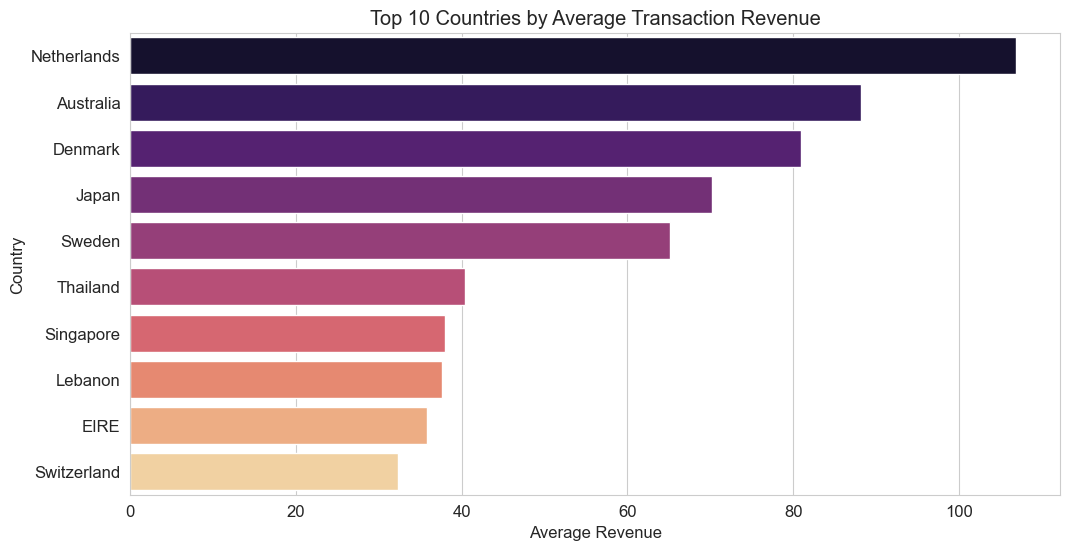

In [51]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_country_revenue.head(10).values,
    y=avg_country_revenue.head(10).index,
    palette="magma"
)

plt.title("Top 10 Countries by Average Transaction Revenue")
plt.xlabel("Average Revenue")
plt.ylabel("Country")

plt.show()

In [52]:
country_orders = (
    df.groupby("Country")
      .size()
      .sort_values(ascending=False)
)

country_orders.head(10)

Country
United Kingdom    716069
Germany            17331
EIRE               16012
France             13896
Netherlands         5132
Spain               3753
Belgium             3109
Switzerland         3057
Portugal            2414
Australia           1887
dtype: int64

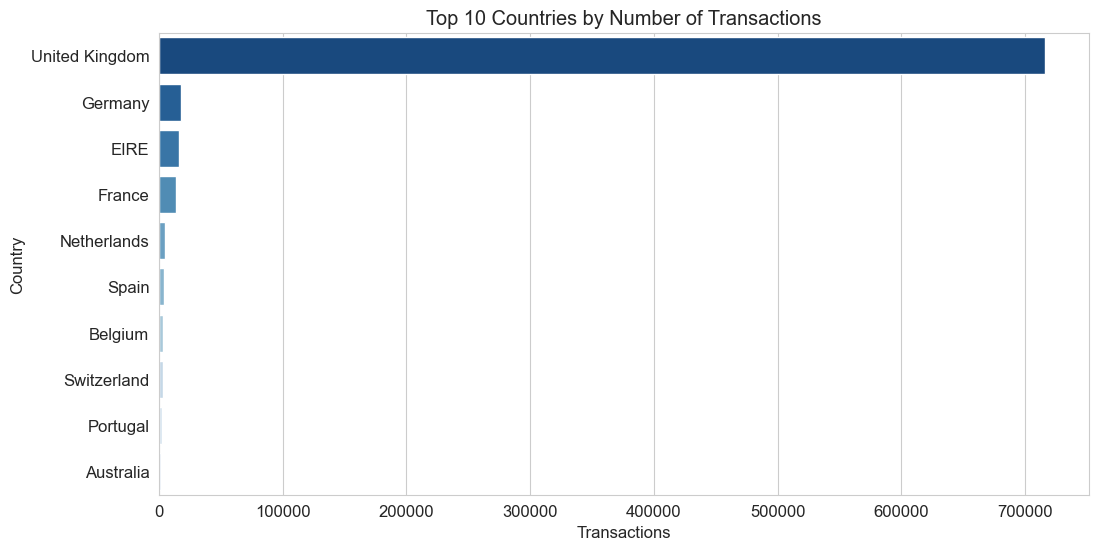

In [53]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=country_orders.head(10).values,
    y=country_orders.head(10).index,
    palette="Blues_r"
)

plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Transactions")
plt.ylabel("Country")

plt.show()

In [54]:
country_summary = (
    df.groupby("Country")
      .agg(
          Total_Revenue=("Revenue","sum"),
          Average_Revenue=("Revenue","mean"),
          Transactions=("Revenue","count")
      )
      .sort_values("Total_Revenue", ascending=False)
)

country_summary.head(10)

,Total_Revenue,Average_Revenue,Transactions
Country,,,
United Kingdom,1.348251e+07,18.828500,716069
EIRE,5.735098e+05,35.817497,16012
Netherlands,5.483307e+05,106.845421,5132
Germany,4.119592e+05,23.770074,17331
France,3.200463e+05,23.031539,13896
Australia,1.664444e+05,88.205840,1887
Switzerland,9.877941e+04,32.312532,3057
Spain,9.101344e+04,24.250850,3753
Sweden,8.742152e+04,65.094207,1343


## Business Insights

### 1. United Kingdom dominates sales

The United Kingdom generated approximately 82.77% of the company's total revenue.

This indicates that the business is heavily dependent on the UK market, making it the primary revenue source.

---

### 2. Revenue is highly concentrated

Although customers belong to many countries, only a handful contribute significantly to total sales.

The remaining countries together account for less than 20% of overall revenue.

---

### 3. Netherlands has the highest average transaction value

Despite having far fewer transactions than the UK, the Netherlands records the highest average revenue per transaction.

This suggests that Dutch customers purchase higher-value products or larger baskets.

---

### 4. Transaction volume drives UK revenue

The UK processed over 716,000 transactions, far exceeding every other country.

Its high revenue is primarily driven by transaction volume rather than unusually high order values.

---

### 5. Opportunity for international expansion

Countries such as Australia, Denmark, Sweden and the Netherlands demonstrate relatively high average transaction values.

Increasing customer acquisition in these markets could substantially increase total revenue.



# 7. Customer Analysis

This section focuses on customer purchasing behavior.

Objectives:

- Analyze customer distribution.
- Identify top revenue-generating customers.
- Study purchase frequency.
- Discover repeat customers.
- Prepare the dataset for customer segmentation in the next phase.

In [55]:
print(f"Unique Customers : {df['CustomerID'].nunique():,}")

Unique Customers : 5,939


In [56]:
customer_revenue = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

customer_revenue.head(10)

CustomerID
18102.0    570380.61
14646.0    523342.07
14156.0    296063.44
14911.0    265757.91
17450.0    231390.55
13694.0    190020.84
17511.0    168491.62
12415.0    143269.29
16684.0    141502.25
15061.0    124961.98
Name: Revenue, dtype: float64

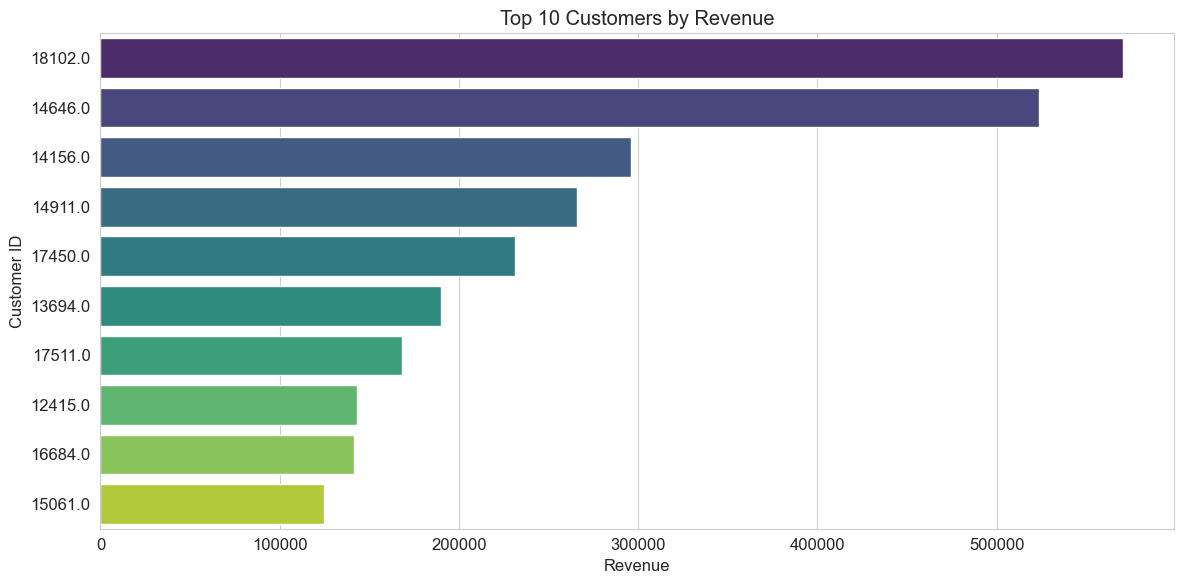

In [57]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=customer_revenue.head(10).values,
    y=customer_revenue.head(10).index.astype(str),
    palette="viridis"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()

plt.savefig(
    "../reports/figures/top_customers_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
customer_frequency = (
    df.groupby("CustomerID")
      .size()
      .sort_values(ascending=False)
)

customer_frequency.head(10)

CustomerID
17841.0    12638
14911.0    11442
12748.0     6660
14606.0     6500
14096.0     5128
15311.0     4579
14156.0     4118
14646.0     3885
13089.0     3390
16549.0     3098
dtype: int64

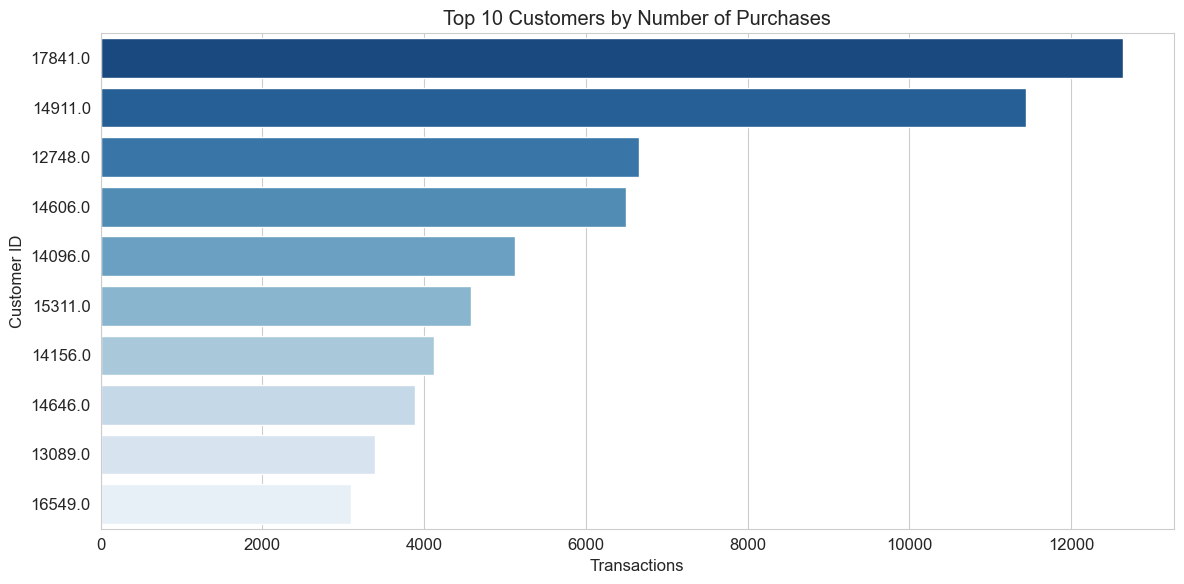

In [59]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=customer_frequency.head(10).values,
    y=customer_frequency.head(10).index.astype(str),
    palette="Blues_r"
)

plt.title("Top 10 Customers by Number of Purchases")
plt.xlabel("Transactions")
plt.ylabel("Customer ID")
plt.tight_layout()

plt.savefig(
    "../reports/figures/top_customers_orders.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insights

### Customer Base

- The dataset contains **5,939 unique customers**, providing a strong customer base for behavioral analysis and segmentation.

### High-Value Customers

- A small number of customers contribute a disproportionately large share of total revenue.
- Customer **18102** generated the highest total revenue, making them a high-value customer.
- Such customers should receive premium services, personalized offers, and retention-focused campaigns.

### Purchase Frequency

- Customer **17841** completed the highest number of transactions.
- High purchase frequency indicates strong engagement but does not necessarily imply the highest spending.

### Spending Behavior

- Revenue leaders and purchase-frequency leaders are different customers.
- This demonstrates that customers exhibit different purchasing behaviors:
  - High-value customers make fewer but larger purchases.
  - Loyal customers purchase frequently with smaller order values.

### Business Recommendation

The company should identify and target:

- High-Revenue Customers for VIP loyalty programs.
- High-Frequency Customers for retention and subscription programs.

Both customer groups represent different business opportunities.

In [60]:
# NOTE: Year, Month, MonthName, Day, DayName, Hour, Quarter, DayOfWeek,
# Week, IsWeekend, and TimeOfDay are now derived inside src/data/cleaner.py
# and already exist in the canonical dataset loaded above. This cell just
# verifies they are present rather than re-deriving them.
expected_time_columns = [
    "Year", "Month", "MonthName", "Day", "DayName",
    "Hour", "Quarter", "DayOfWeek", "Week", "IsWeekend", "TimeOfDay",
]

missing_time_columns = [c for c in expected_time_columns if c not in df.columns]

assert not missing_time_columns, (
    f"Expected time-based columns missing from the canonical dataset: "
    f"{missing_time_columns}. Re-run the Phase 2 pipeline (DataPipeline().run())."
)

print("All expected time-based columns are present.")


All expected time-based columns are present.


In [61]:
df[
    [
        "InvoiceDate",
        "Year",
        "Month",
        "MonthName",
        "Day",
        "DayName",
        "Hour"
    ]
].head()

,InvoiceDate,Year,Month,MonthName,Day,DayName,Hour
0,2009-12-01 07:45:00,2009,12,December,1,Tuesday,7
1,2009-12-01 07:45:00,2009,12,December,1,Tuesday,7
2,2009-12-01 07:45:00,2009,12,December,1,Tuesday,7
3,2009-12-01 07:45:00,2009,12,December,1,Tuesday,7
4,2009-12-01 07:45:00,2009,12,December,1,Tuesday,7


# 8. Time Series Analysis

Time Series Analysis helps identify trends, seasonality, customer activity patterns, and business growth over time.

The InvoiceDate column is decomposed into several useful features:

- Year
- Month
- Month Name
- Day
- Day Name
- Hour

These derived features enable analysis of monthly, weekly, and hourly purchasing behavior.

In [62]:
monthly_revenue = (
    df.groupby(
        ["Year", "Month"]
    )["Revenue"]
      .sum()
      .reset_index()
)

monthly_revenue["YearMonth"] = (
    monthly_revenue["Year"].astype(str)
    + "-"
    + monthly_revenue["Month"].astype(str).str.zfill(2)
)

In [63]:
monthly_revenue.head()

,Year,Month,Revenue,YearMonth
0,2009,12,660125.100,2009-12
1,2010,1,530436.512,2010-01
2,2010,2,487596.426,2010-02
3,2010,3,633419.311,2010-03
4,2010,4,558007.832,2010-04


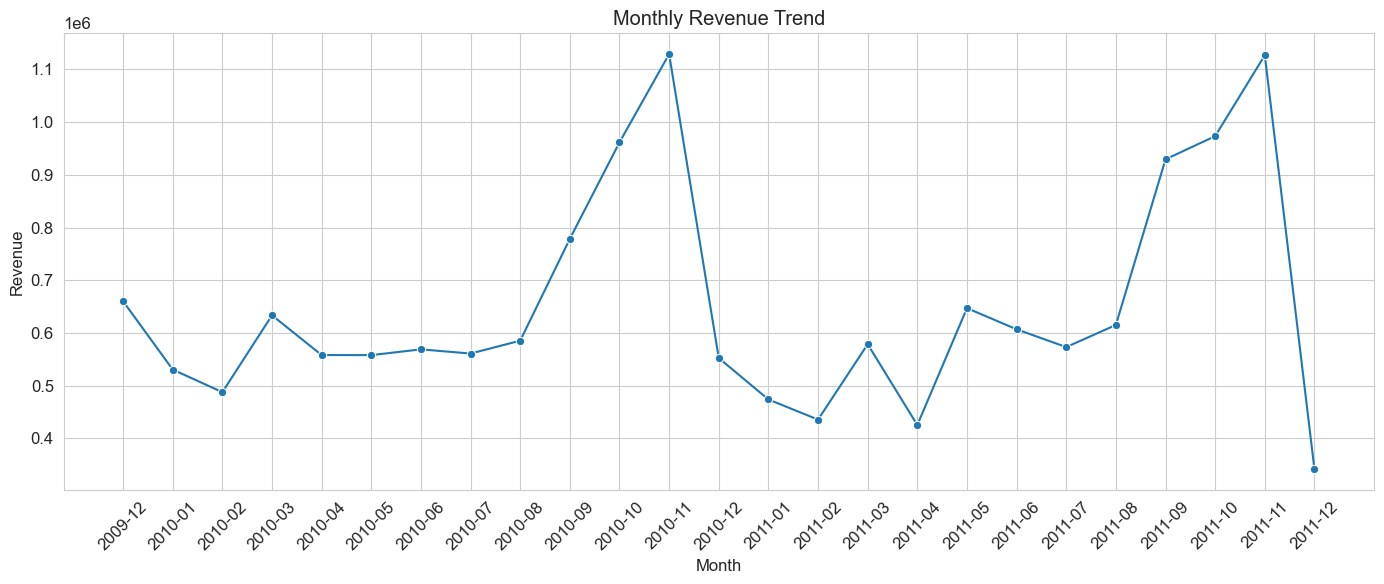

In [64]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_revenue,
    x="YearMonth",
    y="Revenue",
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(
    "../reports/figures/monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Business Insights

### Monthly Revenue Trend

- Revenue exhibits clear seasonality rather than remaining constant throughout the year.
- Sales begin increasing significantly from **September**, continue through **October**, and peak in **November**.
- This pattern repeats across both years, indicating a consistent seasonal purchasing cycle.
- November is the highest revenue-generating month, likely driven by holiday shopping and year-end promotions.
- Revenue appears lower in December because the dataset contains only partial data for December 2011 rather than reflecting an actual decline in business performance.

In [65]:
monthly_orders = (
    df.groupby(["Year", "Month"])
      .size()
      .reset_index(name="Orders")
)

monthly_orders["YearMonth"] = (
    monthly_orders["Year"].astype(str)
    + "-"
    + monthly_orders["Month"].astype(str).str.zfill(2)
)

monthly_orders.head()

,Year,Month,Orders,YearMonth
0,2009,12,31269,2009-12
1,2010,1,22119,2010-01
2,2010,2,23576,2010-02
3,2010,3,32591,2010-03
4,2010,4,27426,2010-04


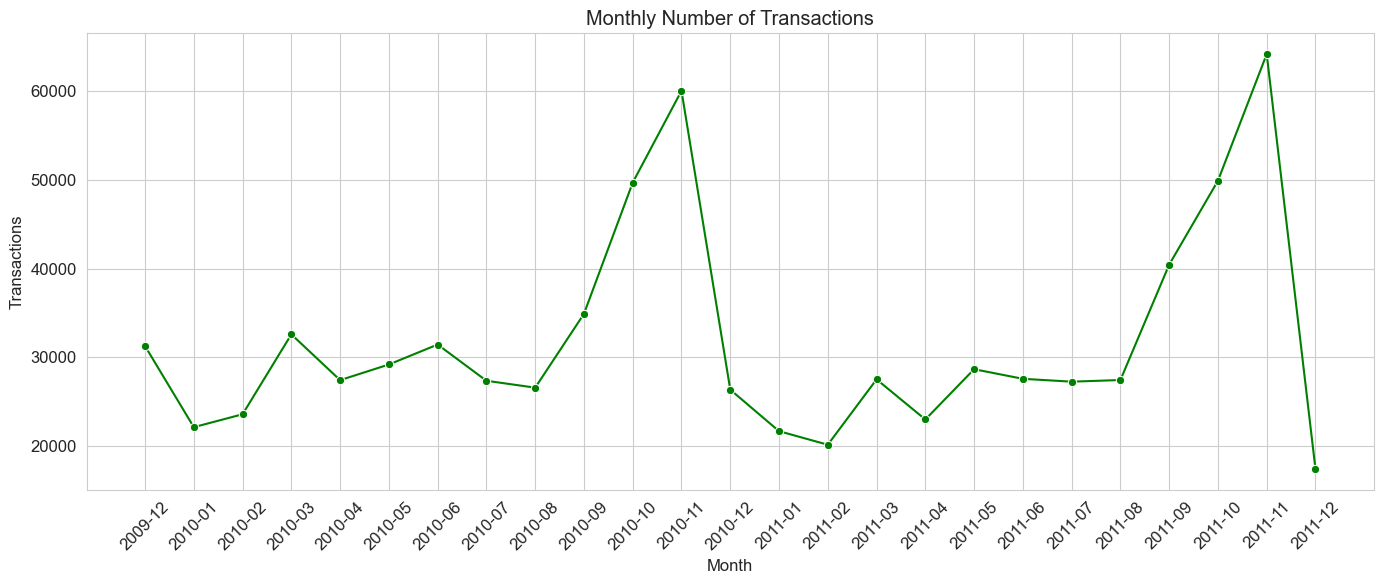

In [66]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_orders,
    x="YearMonth",
    y="Orders",
    marker="o",
    color="green"
)

plt.xticks(rotation=45)

plt.title("Monthly Number of Transactions")

plt.xlabel("Month")

plt.ylabel("Transactions")

plt.tight_layout()

plt.savefig(
    "../reports/figures/monthly_transactions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [67]:
monthly_customers = (
    df.groupby(["Year", "Month"])["CustomerID"]
      .nunique()
      .reset_index(name="Customers")
)

monthly_customers["YearMonth"] = (
    monthly_customers["Year"].astype(str)
    + "-"
    + monthly_customers["Month"].astype(str).str.zfill(2)
)

monthly_customers.head()

,Year,Month,Customers,YearMonth
0,2009,12,1045,2009-12
1,2010,1,786,2010-01
2,2010,2,805,2010-02
3,2010,3,1111,2010-03
4,2010,4,998,2010-04


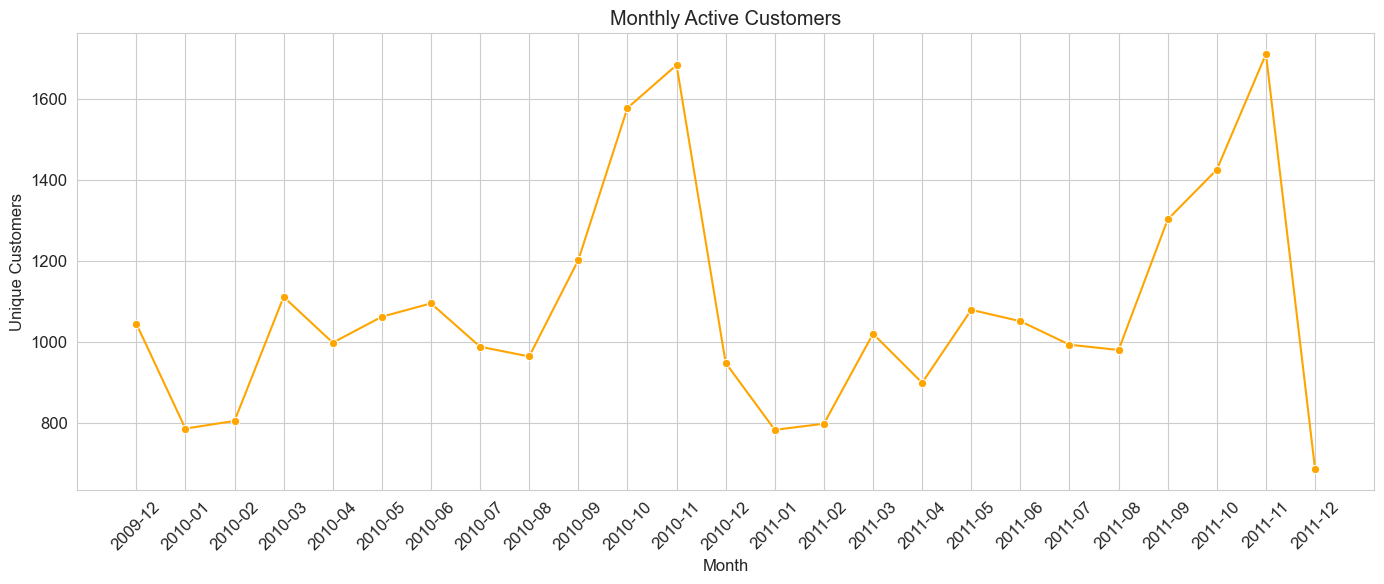

In [68]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_customers,
    x="YearMonth",
    y="Customers",
    marker="o",
    color="orange"
)

plt.xticks(rotation=45)

plt.title("Monthly Active Customers")

plt.xlabel("Month")

plt.ylabel("Unique Customers")

plt.tight_layout()

plt.savefig(
    "../reports/figures/monthly_active_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Monthly Transaction Trend

- Monthly transaction volume remains relatively stable for most of the year.
- A significant increase in transactions is observed from August onward, with peaks in October and November.
- The transaction trend closely follows the monthly revenue trend, indicating that revenue growth is primarily driven by higher purchasing activity.
- The recurring pattern across both years suggests strong seasonal customer behavior.
- The decline in December 2011 is due to incomplete data rather than reduced customer demand.



### Monthly Active Customer Trend

- The number of active customers follows a clear seasonal pattern.
- Customer activity increases significantly during September, October, and November in both years.
- The trend closely matches both revenue and transaction volume, indicating that higher sales are driven by increased customer participation.
- The repeated yearly pattern highlights strong seasonal demand during the holiday shopping period.
- The decline observed in December 2011 is caused by incomplete dataset coverage rather than a reduction in customer engagement.

## Overall Time Series Insights

The monthly analysis reveals a strong seasonal sales pattern.

Revenue, transaction volume, and active customers all increase together during September, October, and November before reaching their highest levels in November. This indicates that revenue growth is primarily driven by an increase in customer activity and purchase frequency rather than only higher spending per transaction.

The same seasonal pattern is observed in both years, suggesting consistent customer purchasing behavior around the holiday season.

The sharp decline in December 2011 should not be interpreted as a business slowdown because the dataset contains only partial transaction records for that month.



In [69]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [70]:
rfm = (
    df.groupby("CustomerID")
      .agg({
          "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
          "InvoiceNo": "nunique",
          "Revenue": "sum"
      })
      .reset_index()
)

In [71]:
rfm.columns = [
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary"
]

In [72]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,17,-51.74
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,5,4404.54
4,12350.0,310,1,334.40


In [73]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,5939.000000,5939.000000,5939.000000,5939.000000
mean,15317.133693,202.784812,7.555144,2742.884541
std,1715.592756,211.727459,15.970199,13679.955199
min,12346.000000,1.000000,1.000000,-25111.090000
25%,13831.500000,25.000000,2.000000,321.365000
50%,15318.000000,96.000000,4.000000,823.530000
75%,16802.500000,381.000000,8.000000,2143.280000
max,18287.000000,739.000000,510.000000,570380.610000


In [74]:
rfm.shape

(5939, 4)

In [75]:
rfm.isnull().sum()

CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

In [76]:
rfm.sample(10)

,CustomerID,Recency,Frequency,Monetary
3272,15621.0,4,6,1158.77
5779,18128.0,537,1,399.29
663,13009.0,673,1,234.00
4666,17015.0,29,3,1838.61
95,12441.0,367,1,173.55
2333,14681.0,71,6,875.15
5888,18237.0,3,5,987.10
2862,15211.0,60,2,894.41
3469,15818.0,588,1,340.50
511,12857.0,211,7,3684.25


In [77]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5,4,3,2,1]
)

In [78]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1,2,3,4,5]
)

In [79]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1,2,3,4,5]
)

In [80]:
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

In [81]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

In [82]:
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,17,-51.74,2,5,1,251
1,12347.0,2,8,4921.53,5,4,5,545
2,12348.0,75,5,2019.40,3,3,4,334
3,12349.0,19,5,4404.54,4,3,5,435
4,12350.0,310,1,334.40,2,1,2,212
5,12351.0,375,1,300.93,2,1,2,212
6,12352.0,36,13,1889.21,4,5,4,454
7,12353.0,204,2,406.76,2,2,2,222
8,12354.0,232,1,1079.40,2,1,3,213
9,12355.0,214,2,947.61,2,2,3,223


In [83]:
rfm["RFM_Score"].value_counts().head(20)

RFM_Score
555    482
111    349
455    243
211    177
344    164
121    158
222    152
444    148
112    136
544    133
355    129
122    129
233    128
333    109
433    109
221    102
212     98
311     92
554     90
533     89
Name: count, dtype: int64

## RFM Scoring

The raw RFM metrics are transformed into standardized scores ranging from 1 to 5 using quintile-based ranking.

- **Recency Score:** Customers with more recent purchases receive higher scores.
- **Frequency Score:** Customers with more purchase transactions receive higher scores.
- **Monetary Score:** Customers with higher total spending receive higher scores.

The three scores are combined into a three-digit RFM score that represents each customer's purchasing behavior and forms the basis for customer segmentation.

# 9. Customer Segmentation using RFM

Raw RFM scores are translated into meaningful business segments that represent different customer behaviors.

Instead of analyzing individual scores, customers are grouped into strategic categories such as Champions, Loyal Customers, Potential Loyalists, At Risk, and Lost Customers.

These segments help businesses personalize marketing campaigns, improve customer retention, reduce churn, and maximize customer lifetime value.

In [84]:
def customer_segment(row):

    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    # Champions
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    # Loyal Customers
    elif r >= 3 and f >= 4:
        return "Loyal Customers"

    # Potential Loyalists
    elif r >= 4 and f >= 2:
        return "Potential Loyalists"

    # Big Spenders
    elif m >= 4:
        return "Big Spenders"

    # At Risk
    elif r <= 2 and f >= 3:
        return "At Risk"

    # Lost Customers
    elif r == 1 and f <= 2:
        return "Lost Customers"

    # New Customers
    elif r == 5 and f == 1:
        return "New Customers"

    else:
        return "Others"

In [85]:
rfm["Segment"] = rfm.apply(customer_segment, axis=1)

In [86]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,17,-51.74,2,5,1,251,At Risk
1,12347.0,2,8,4921.53,5,4,5,545,Champions
2,12348.0,75,5,2019.40,3,3,4,334,Big Spenders
3,12349.0,19,5,4404.54,4,3,5,435,Potential Loyalists
4,12350.0,310,1,334.40,2,1,2,212,Others


In [87]:
rfm["Segment"].value_counts()

Segment
Champions              1303
Others                 1274
Lost Customers          864
Potential Loyalists     736
Loyal Customers         702
At Risk                 508
Big Spenders            505
New Customers            47
Name: count, dtype: int64

In [88]:
segment_summary = (

    rfm
    .groupby("Segment")
    .agg({

        "CustomerID":"count",
        "Recency":"mean",
        "Frequency":"mean",
        "Monetary":"mean"

    })

)

segment_summary.rename(columns={

    "CustomerID":"Customers"

}, inplace=True)

segment_summary

,Customers,Recency,Frequency,Monetary
Segment,,,,
At Risk,508,383.320866,4.312992,562.266535
Big Spenders,505,301.174257,6.596040,2781.628723
Champions,1303,18.775902,20.884881,8780.033849
Lost Customers,864,568.403935,1.267361,199.479978
Loyal Customers,702,85.425926,9.474359,2601.875222
New Customers,47,9.468085,1.000000,301.661915
Others,1274,206.616170,1.691523,387.247081
Potential Loyalists,736,24.877717,2.971467,887.031630


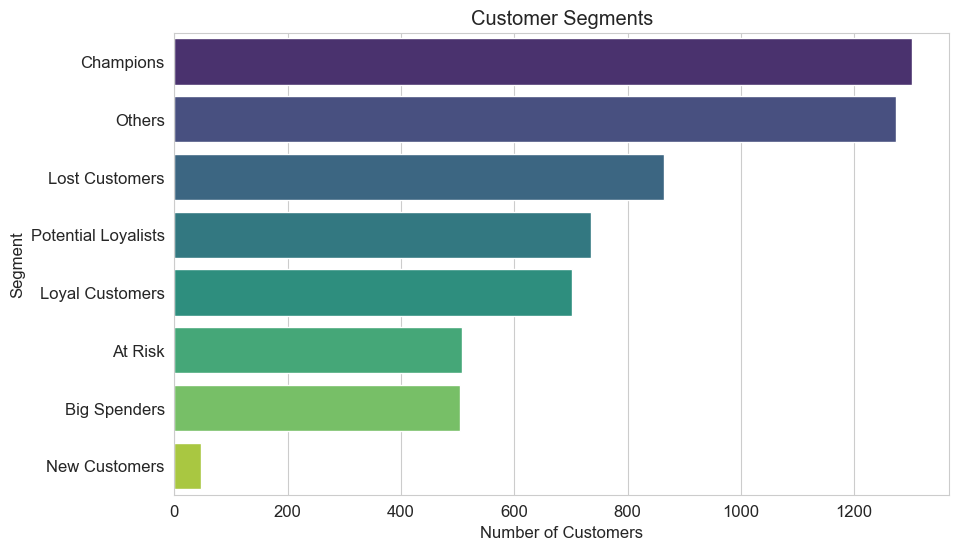

In [89]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=rfm,
    y="Segment",
    order=rfm["Segment"].value_counts().index,
    palette="viridis"
)

plt.title("Customer Segments")

plt.xlabel("Number of Customers")

plt.ylabel("Segment")

plt.show()

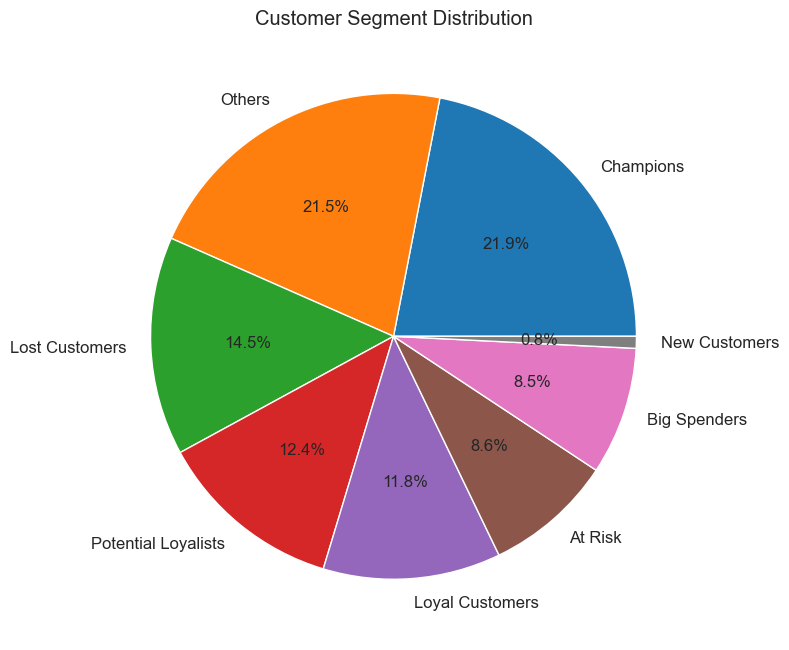

In [90]:
plt.figure(figsize=(8,8))

rfm["Segment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Customer Segment Distribution")

plt.tight_layout()

plt.savefig(
    "../reports/figures/customer_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [91]:
segment_revenue = (

    rfm
    .groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)

)

segment_revenue

Segment
Champions              1.144038e+07
Loyal Customers        1.826516e+06
Big Spenders           1.404723e+06
Potential Loyalists    6.528553e+05
Others                 4.933528e+05
At Risk                2.856314e+05
Lost Customers         1.723507e+05
New Customers          1.417811e+04
Name: Monetary, dtype: float64

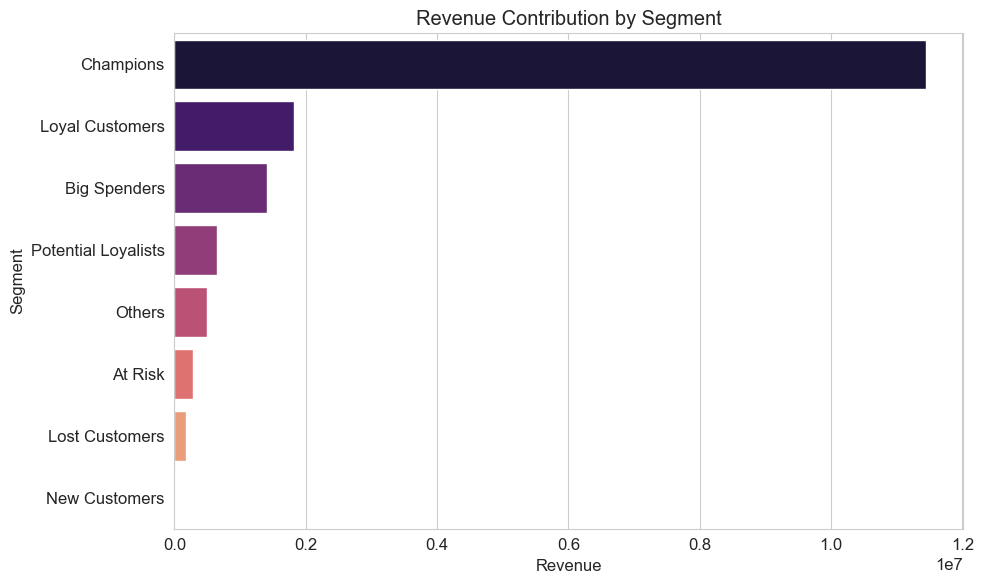

In [92]:
plt.figure(figsize=(10,6))

sns.barplot(

    x=segment_revenue.values,
    y=segment_revenue.index,
    palette="magma"

)

plt.title("Revenue Contribution by Segment")

plt.xlabel("Revenue")

plt.ylabel("Segment")

plt.tight_layout()

plt.savefig(
    "../reports/figures/revenue_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insights

The customer segmentation analysis reveals distinct groups of customers with different purchasing behaviors.

- Champions represent the most valuable customers with recent, frequent, and high-value purchases.
- Loyal Customers purchase consistently and contribute significant revenue.
- Potential Loyalists have recently engaged with the business and can become long-term customers.
- At Risk customers were valuable previously but have reduced their activity.
- Lost Customers have not purchased recently and require re-engagement strategies.
- Big Spenders generate high revenue despite varying purchase frequency.
- These segments provide a strong foundation for personalized marketing campaigns and customer retention initiatives.

# 10. Correlation Analysis

Correlation analysis helps identify relationships between numerical variables.

Understanding these relationships assists in feature engineering, customer behavior analysis, and future predictive modeling.

### Transaction Level Correlation

In [93]:
transaction_corr = df[
    [
        "Quantity",
        "UnitPrice",
        "Revenue"
    ]
].corr()

transaction_corr

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.001919,0.856269
UnitPrice,-0.001919,1.000000,-0.150721
Revenue,0.856269,-0.150721,1.000000


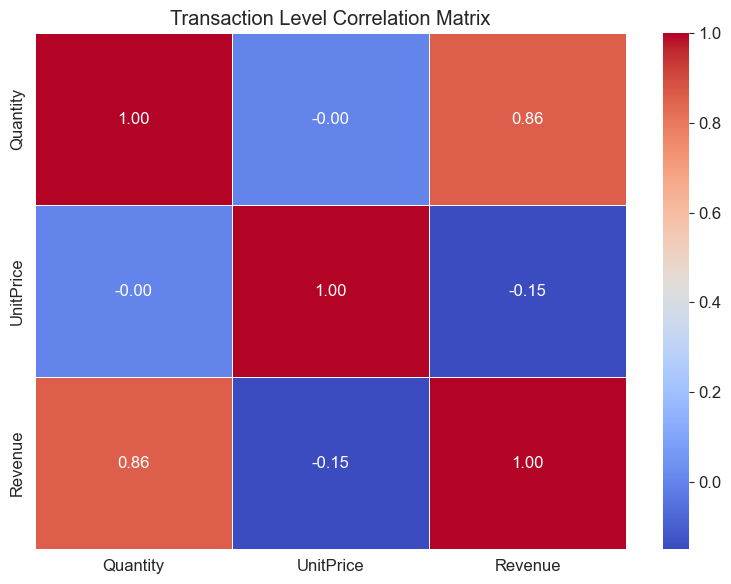

In [94]:
plt.figure(figsize=(8,6))

sns.heatmap(
    transaction_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Transaction Level Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../reports/figures/transaction_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight

• Revenue has a strong positive relationship with Quantity.

• UnitPrice contributes positively toward Revenue.

• Quantity and UnitPrice show relatively weak correlation because products with higher prices are not necessarily purchased in larger quantities.

### Customer Level Correlation (RFM)

In [95]:
rfm_corr = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
].corr()

rfm_corr

,Recency,Frequency,Monetary
Recency,1.000000,-0.257156,-0.130351
Frequency,-0.257156,1.000000,0.614601
Monetary,-0.130351,0.614601,1.000000


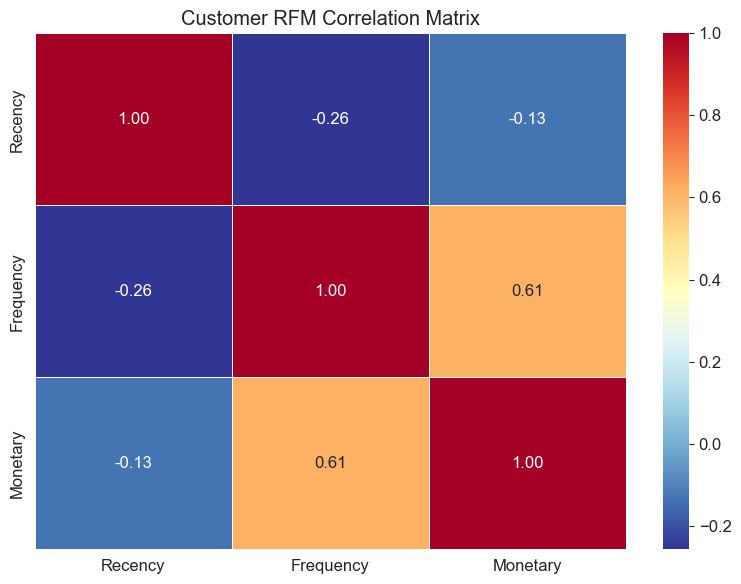

In [96]:
plt.figure(figsize=(8,6))

sns.heatmap(
    rfm_corr,
    annot=True,
    cmap="RdYlBu_r",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Customer RFM Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../reports/figures/rfm_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight

• Frequency and Monetary usually have a strong positive relationship.

• Customers purchasing frequently generally spend more.

• Recency generally has a negative relationship with Frequency and Monetary, indicating inactive customers purchase less.

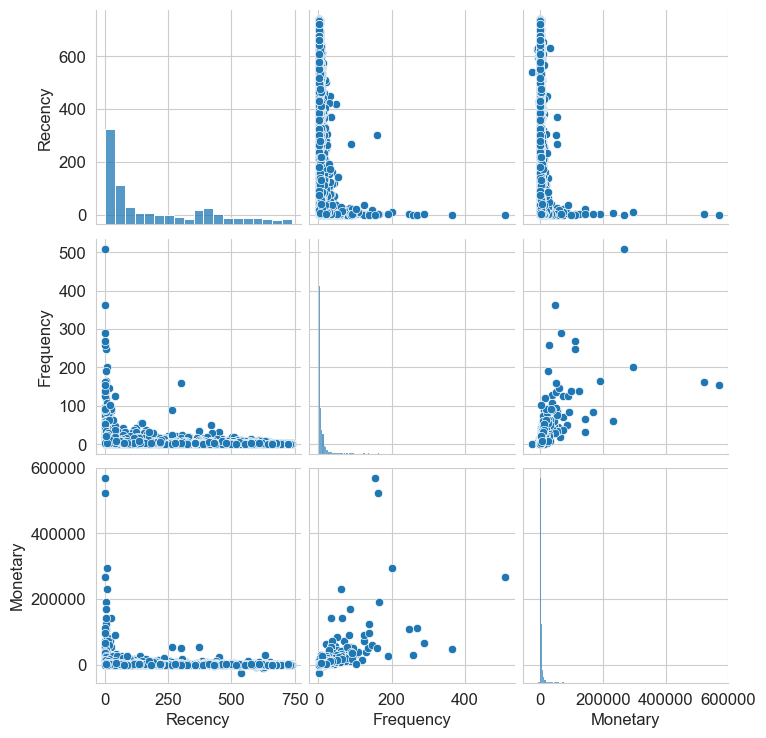

In [97]:
sns.pairplot(
    rfm[
        [
            "Recency",
            "Frequency",
            "Monetary"
        ]
    ]
)

plt.show()

### Business Insight

The pairplot provides a visual understanding of relationships between RFM variables.

It also helps identify customer clusters and potential outliers.

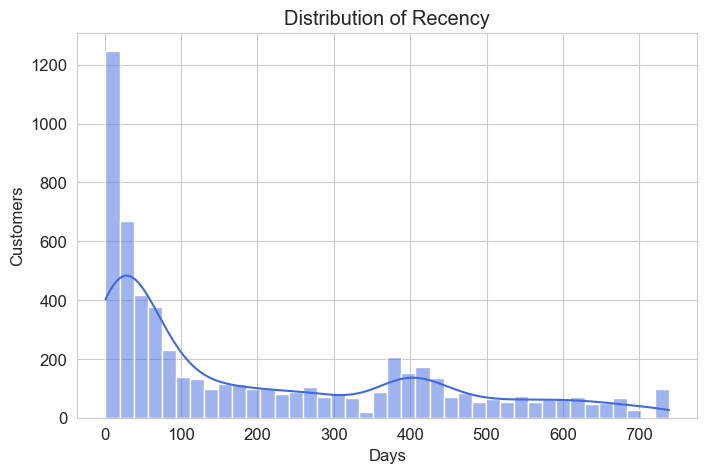

In [98]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm["Recency"],
    bins=40,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Recency")

plt.xlabel("Days")

plt.ylabel("Customers")

plt.show()

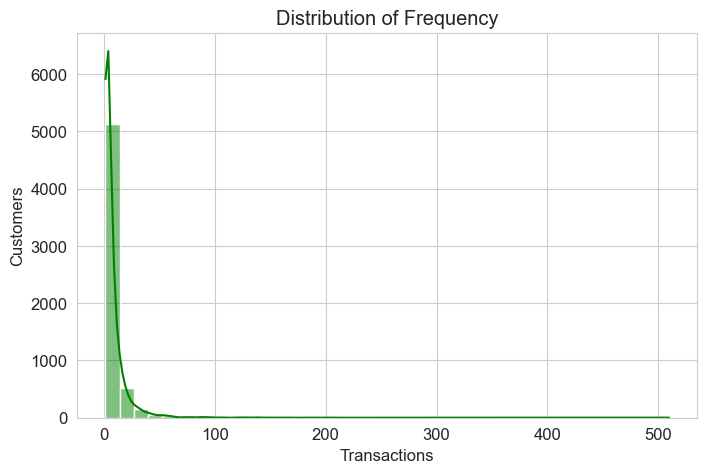

In [99]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm["Frequency"],
    bins=40,
    kde=True,
    color="green"
)

plt.title("Distribution of Frequency")

plt.xlabel("Transactions")

plt.ylabel("Customers")

plt.show()

### Business Insight

The RFM distributions are highly skewed.

Most customers purchase infrequently and spend relatively small amounts, while a small percentage contribute exceptionally high revenue.

This confirms the Pareto Principle (80/20 rule), where a minority of customers generate the majority of revenue.

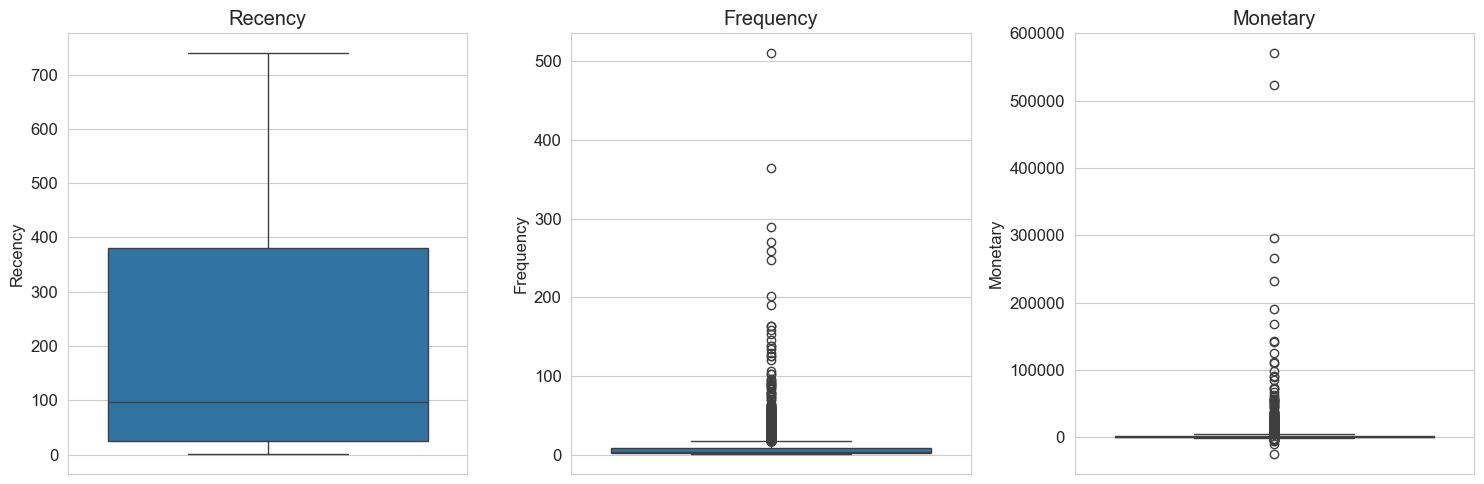

In [100]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=rfm["Recency"])
plt.title("Recency")

plt.subplot(1,3,2)
sns.boxplot(y=rfm["Frequency"])
plt.title("Frequency")

plt.subplot(1,3,3)
sns.boxplot(y=rfm["Monetary"])
plt.title("Monetary")

plt.tight_layout()

plt.show()

### Business Insight

The presence of significant outliers is expected in retail customer data.

These represent high-value customers rather than data errors, so they should be retained for customer segmentation and business analysis.

# M11. Business Insights & Recommendations

The previous exploratory data analysis identified important patterns in customer purchasing behavior, sales trends, product performance, and customer segmentation.

This section summarizes the key findings and converts them into actionable business recommendations that can help improve customer retention, increase revenue, and support data-driven decision making.

## Executive Summary

The analysis was performed on the Online Retail II transactional dataset covering approximately two years of customer purchases.

Major analyses included:

- Customer purchasing behavior
- Product performance
- Country-wise sales
- Monthly revenue trends
- Customer segmentation using RFM Analysis
- Correlation analysis

The objective was to understand customer behavior and generate business insights that can improve marketing strategies and overall business performance.

In [101]:
summary = pd.DataFrame({
    "Metric":[
        "Total Transactions",
        "Unique Customers",
        "Unique Products",
        "Countries",
        "Total Revenue"
    ],
    "Value":[
        len(df),
        df["CustomerID"].nunique(),
        df["StockCode"].nunique(),
        df["Country"].nunique(),
        round(df["Revenue"].sum(),2)
    ]
})

summary

,Metric,Value
0,Total Transactions,797815.00
1,Unique Customers,5939.00
2,Unique Products,4646.00
3,Countries,41.00
4,Total Revenue,16289991.29


### Business Insight

The dataset contains a large volume of customer transactions across multiple countries and products, providing sufficient information to understand purchasing behavior and perform customer segmentation.

## Customer Insights

- More than five thousand unique customers purchased products during the analysis period.

- A relatively small number of customers generated a significant portion of total revenue.

- Repeat customers contributed considerably more revenue than one-time purchasers.

- Customer purchasing behavior follows the Pareto Principle, where a minority of customers contributes the majority of business revenue.

## Product Insights

- Some products were purchased significantly more frequently than others.

- High-demand products can be prioritized for inventory planning.


- Certain premium-priced products generated substantial revenue despite lower sales volume.

## Geographic Insights

- The United Kingdom contributed the largest share of revenue.

- International customers contributed additional revenue but represented a smaller proportion of overall sales.

- Expanding successful product lines into international markets could increase revenue.

## Time Series Insights

- Monthly revenue exhibited clear seasonal fluctuations.

- Revenue increased substantially during the final quarter of each year.

- November recorded the highest revenue across both years, indicating strong holiday-season demand.

- Business performance was relatively stable during other months.

## Customer Segmentation Insights

RFM analysis divided customers into several business-oriented groups.

- Champions generated the highest revenue.

- Loyal Customers consistently purchased products over time.

- Potential Loyalists showed strong potential for future growth.

- At Risk customers had previously purchased but had recently become inactive.

- Lost Customers represented inactive customers requiring re-engagement campaigns.

- New Customers formed a small proportion of the customer base and require onboarding strategies.

# Business Recommendations

Based on the exploratory analysis, the following recommendations are proposed.

### Recommendation 1

Develop loyalty programs exclusively for Champions and Loyal Customers to improve retention.

---

### Recommendation 2

Launch personalized email campaigns for At Risk and Lost Customers to encourage repeat purchases.

---

### Recommendation 3

Target Potential Loyalists with discount coupons to convert them into long-term customers.

---

### Recommendation 4

Recommend premium products to Big Spenders through personalized marketing.

---

### Recommendation 5

Maintain sufficient inventory for high-demand products, especially before peak shopping months.

---

### Recommendation 6

Increase marketing investment before October and November to maximize seasonal sales.

---

### Recommendation 7

Expand successful products into international markets to diversify revenue sources.

---

### Recommendation 8

Create onboarding campaigns for New Customers to increase customer retention after their first purchase.

# Business Value

This analysis demonstrates how transaction-level retail data can be transformed into meaningful business intelligence.

The generated insights can help organizations:

- Improve customer retention
- Increase customer lifetime value
- Identify high-value customer segments
- Optimize inventory management
- Support personalized marketing campaigns
- Improve revenue forecasting
- Enable data-driven business decision making

# Conclusion

This exploratory data analysis successfully transformed raw transactional data into actionable business insights.

The project explored customer purchasing behavior, sales trends, product performance, geographic distribution, and customer segmentation using the RFM framework.

The analysis identified high-value customer groups, seasonal revenue patterns, and opportunities for improving customer retention and marketing effectiveness.

These findings provide a strong foundation for building predictive machine learning models and developing an interactive customer analytics dashboard in the next phases of the project.

In [102]:
# NOTE: final_cleaned_dataset.csv is now produced by src/data/cleaner.py
# (via DataPipeline().run()) as part of Phase 2, not saved here. This
# notebook only exports the exploratory RFM table for reference.
rfm.to_csv(
    "../data/processed/customer_rfm.csv",
    index=False
)


In [103]:
kpi = pd.DataFrame({

    "Metric":[
        "Total Revenue",
        "Customers",
        "Transactions",
        "Countries",
        "Champions",
        "Lost Customers"
    ],

    "Value":[
        round(df["Revenue"].sum(),2),
        df["CustomerID"].nunique(),
        len(df),
        df["Country"].nunique(),
        (rfm["Segment"]=="Champions").sum(),
        (rfm["Segment"]=="Lost Customers").sum()
    ]
})

kpi

,Metric,Value
0,Total Revenue,16289991.29
1,Customers,5939.00
2,Transactions,797815.00
3,Countries,41.00
4,Champions,1303.00
5,Lost Customers,864.00
